
# TFG Matemáticas y Física — Capítulo 4  
## Diseño computacional en Python

Este notebook recopila en un único archivo los programas en Python propuestos para el **Capítulo 4** del TFG sobre **redes neuronales energéticas**.

Incluye:

- utilidades para patrones binarios,
- implementación de una **red de Hopfield**,
- reconstrucción de patrones con ruido,
- experimentos de robustez y capacidad,
- visualización de un paisaje energético discreto,
- distribución de Boltzmann y efecto de la temperatura,
- **RBM con `BernoulliRBM`** de scikit-learn sobre `digits`,
- implementación opcional y didáctica de una **RBM en PyTorch**.


## 1. Librerías y configuración


In [13]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
import sklearn

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import BernoulliRBM

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["image.cmap"] = "gray"
np.set_printoptions(edgeitems=10, linewidth=120, suppress=True)

print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)

NumPy: 2.1.3
scikit-learn: 1.6.1



## 2. Utilidades para patrones binarios


In [14]:
def binarize_pattern(x, threshold=0.5):
    """Convierte un array en valores {-1, 1}."""
    x = np.asarray(x)
    return np.where(x > threshold, 1, -1) #1 si es mayor que threshold

def add_noise(pattern, noise_level=0.2, rng=None):
    """Invierte aleatoriamente una fracción de bits del patrón."""
    rng = np.random.default_rng(rng) 
    noisy = np.array(pattern, copy=True)
    n_flip = int(noise_level * noisy.size)
    if n_flip > 0:
        idx = rng.choice(noisy.size, size=n_flip, replace=False) #elección aleatoria de las posiciones invertidas
        noisy[idx] *= -1
    return noisy

def plot_pattern(pattern, shape, title=""):
    plt.imshow(np.asarray(pattern).reshape(shape), cmap="gray") #transforma vector en matriz para poer representarlo en escalated de grises
    plt.title(title, fontsize=20)
    plt.axis("off")


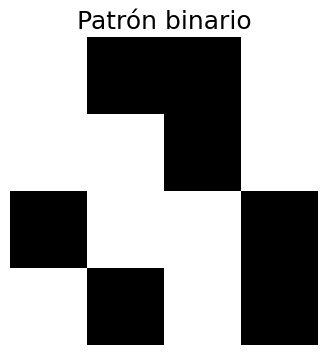

In [15]:
patron = np.array([
    1,-1,-1,1,
    1,1,-1,1,
    -1,1,1,-1,
    1,-1,1,-1
])

plot_pattern(patron, (4, 4))
plt.title("Patrón binario",fontsize=18)
plt.savefig("patron_binario.png", dpi=300)
plt.show()


## 3. Red de Hopfield
La implementación siguiente incluye:

- entrenamiento por **regla de Hebb**,
- cálculo de la **energía**,
- actualización **asíncrona**,
- medida de **solapamiento** entre patrones.


In [16]:
class HopfieldNetwork:
    def __init__(self):
        self.W = None
        self.n_units = None

    def fit(self, patterns):
        """
        patterns: array de forma (n_patrones, n_neuronas), con valores {-1, 1}
        """
        patterns = np.asarray(patterns)
        n_patterns, n_units = patterns.shape
        self.n_units = n_units

        W = np.zeros((n_units, n_units), dtype=float)
        for p in patterns:
            W += np.outer(p, p)

        W /= n_units
        np.fill_diagonal(W, 0.0)
        self.W = W
        return self

    def energy(self, state):
        state = np.asarray(state)
        return -0.5 * state @ self.W @ state

    def local_field(self, state, i):
        return np.dot(self.W[i], state)

    def update_async(self, state, max_iter=100, rng=None, return_history=False):
        rng = np.random.default_rng(rng)
        state = np.array(state, copy=True)
        energy_history = [self.energy(state)]
        state_history = [state.copy()]

        for _ in range(max_iter):
            changed = False
            indices = rng.permutation(self.n_units)

            for i in indices:
                h_i = self.local_field(state, i)
                new_value = 1 if h_i >= 0 else -1
                if new_value != state[i]:
                    state[i] = new_value
                    changed = True

            energy_history.append(self.energy(state))
            state_history.append(state.copy())

            if not changed:
                break

        if return_history:
            return state, energy_history, state_history
        return state

    def overlap(self, a, b):
        a = np.asarray(a)
        b = np.asarray(b)
        return np.dot(a, b) / len(a)



## 4. Patrones sintéticos 5x5
Usaremos tres patrones binarios sencillos para ilustrar memoria asociativa.


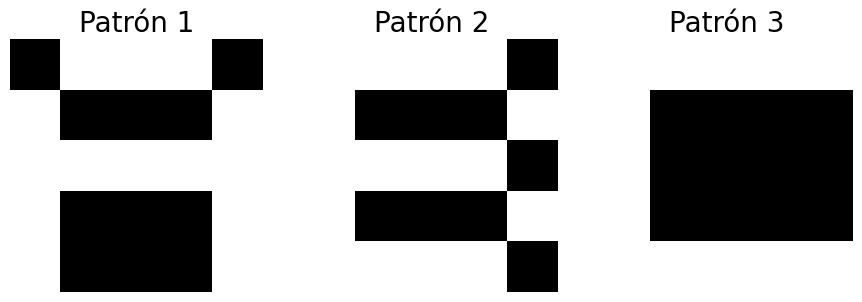

In [17]:
patterns = np.array([
    [-1, 1, 1, 1,-1,
      1,-1,-1,-1, 1,
      1, 1, 1, 1, 1,
      1,-1,-1,-1, 1,
      1,-1,-1,-1, 1],   # A simplificada

    [ 1, 1, 1, 1,-1,
      1,-1,-1,-1, 1,
      1, 1, 1, 1,-1,
      1,-1,-1,-1, 1,
      1, 1, 1, 1,-1],   # B simplificada

    [ 1, 1, 1, 1, 1,
      1,-1,-1,-1,-1,
      1,-1,-1,-1,-1,
      1,-1,-1,-1,-1,
      1, 1, 1, 1, 1]    # C simplificada
], dtype=int)

plt.figure(figsize=(9, 3))
for i, p in enumerate(patterns):
    plt.subplot(1, 3, i + 1)
    plot_pattern(p, (5, 5), f"Patrón {i+1}")
plt.tight_layout()
plt.savefig("patrones_almacenados.png", dpi=300)
plt.show()



## 5. Reconstrucción de patrones ruidosos en Hopfield


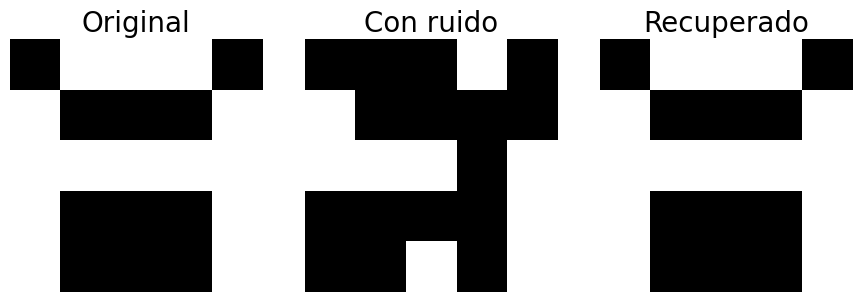

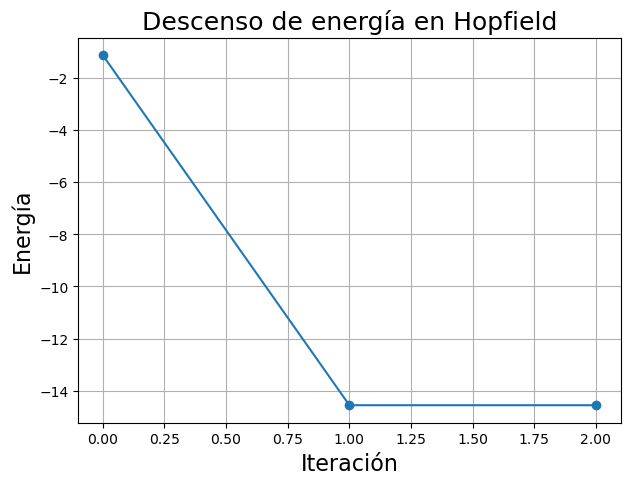

Solapamiento original-recuperado: 1.0


In [18]:
hopfield = HopfieldNetwork().fit(patterns)

original = patterns[0]
noisy = add_noise(original, noise_level=0.30, rng=42)
recovered, energies, states = hopfield.update_async(noisy, max_iter=30, rng=42, return_history=True)

plt.figure(figsize=(9, 3))
plt.subplot(1, 3, 1)
plot_pattern(original, (5, 5), "Original")

plt.subplot(1, 3, 2)
plot_pattern(noisy, (5, 5), "Con ruido")

plt.subplot(1, 3, 3)
plot_pattern(recovered, (5, 5), "Recuperado")
plt.tight_layout()
plt.savefig("hopfield_recuperacion.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(energies, marker="o")
plt.xlabel("Iteración",fontsize=16)
plt.ylabel("Energía",fontsize=16)
plt.title("Descenso de energía en Hopfield",fontsize=18)
plt.grid(True)
plt.savefig("descenso_e_recuperacion.png", dpi=300)
plt.show()

print("Solapamiento original-recuperado:", hopfield.overlap(original, recovered))



## 6. Experimento de capacidad y robustez frente al ruido
Se mide la tasa de recuperación en función del número de patrones almacenados y del nivel de ruido.


In [19]:

def random_patterns(n_patterns, n_units, rng=None):
    rng = np.random.default_rng(rng)
    return rng.choice([-1, 1], size=(n_patterns, n_units))

def recovery_rate(n_units=100, n_patterns=5, noise_level=0.2, trials=20, rng=None):
    rng = np.random.default_rng(rng)
    success = 0

    patterns = random_patterns(n_patterns, n_units, rng)
    net = HopfieldNetwork().fit(patterns)

    for _ in range(trials): #nº de pruebas
        idx = rng.integers(0, n_patterns) #escoge aleatoriamente un indice entre 0 y n_patterns-1
        original = patterns[idx]   #escoge el patrón en esa posición
        noisy = add_noise(original, noise_level=noise_level, rng=rng) #genera una versión ruidosa
        recovered = net.update_async(noisy, max_iter=50, rng=rng) #patron reccuperado por la red
        if np.array_equal(recovered, original): #si son iguales
            success += 1 #ha recuperado correctamente

    return success / trials #tasa


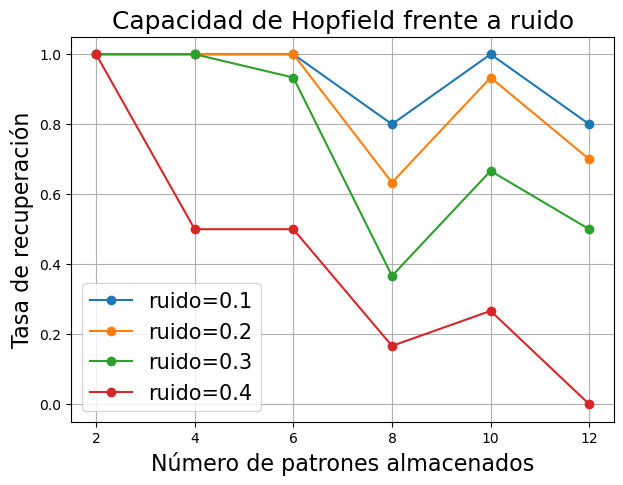

In [20]:
n_units = 100
pattern_counts = [2, 4, 6, 8, 10, 12]
noise_levels = [0.1, 0.2, 0.3, 0.4]

results = {}
for noise in noise_levels:
    results[noise] = [
        recovery_rate(
            n_units=n_units,
            n_patterns=p,
            noise_level=noise,
            trials=30,
            rng=1234 + p
        )
        for p in pattern_counts
    ]

plt.figure(figsize=(7, 5))
for noise, rates in results.items():
    plt.plot(pattern_counts, rates, marker="o", label=f"ruido={noise}")
plt.xlabel("Número de patrones almacenados",fontsize=16)
plt.ylabel("Tasa de recuperación",fontsize=16)
plt.title("Capacidad de Hopfield frente a ruido",fontsize=18)
plt.legend(fontsize=15)
plt.grid(True)
plt.savefig("capacidaad.png", dpi=300)
plt.show()


## 7. Paisaje energético discreto
Para un sistema pequeño, se pueden enumerar todos los microestados y representar sus energías.


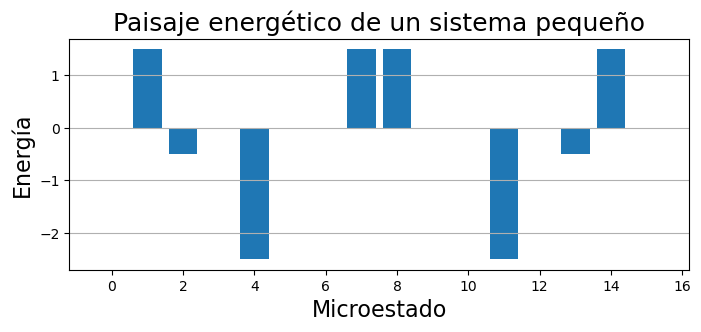

In [21]:
def enumerate_energies(W):    
    n = W.shape[0]
    states = np.array(list(itertools.product([-1, 1], repeat=n)))
    energies = np.array([-0.5 * s @ W @ s for s in states])
    return states, energies

# Patrones que se desean almacenar
patterns_small = np.array([
    [-1, -1,  1, -1],   # p2
    [-1,  1, -1, -1],   # p4
    [ 1, -1,  1,  1]    # p11
])

# Matriz entrenada con la regla de Hebb implementada en HopfieldNetwork.fit()
W_small = HopfieldNetwork().fit(patterns_small).W
states, energies = enumerate_energies(W_small)


plt.figure(figsize=(8, 3))
plt.bar(range(len(energies)), energies)
plt.xlabel("Microestado",fontsize=16)
plt.ylabel("Energía",fontsize=16)
plt.title("Paisaje energético de un sistema pequeño",fontsize=18)
plt.grid(True, axis="y")
plt.savefig("paisaje.png", dpi=300, bbox_inches="tight", pad_inches=0.3)
plt.show()


## 8. Distribución de Boltzmann y efecto de la temperatura


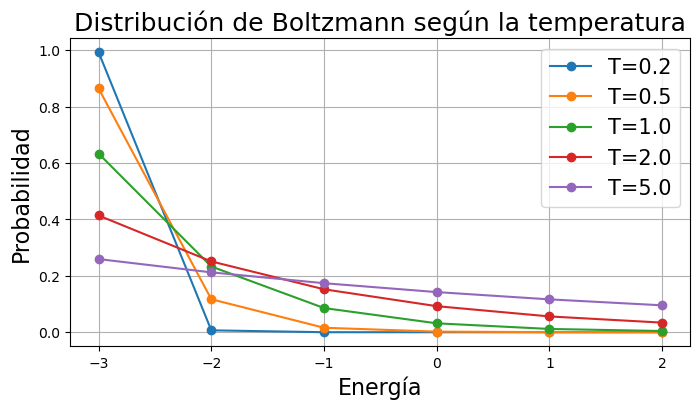

In [22]:
energies_example = np.array([-3, -2, -1, 0, 1, 2], dtype=float)

def boltzmann_probs(energies, T):
    beta = 1.0 / T
    logits = np.exp(-beta * energies)
    return logits / logits.sum()

temperatures = [0.2, 0.5, 1.0, 2.0, 5.0]

plt.figure(figsize=(8, 4))
for T in temperatures:
    p = boltzmann_probs(energies_example, T)
    plt.plot(energies_example, p, marker="o", label=f"T={T}")
plt.xlabel("Energía",fontsize=16)
plt.ylabel("Probabilidad",fontsize=16)
plt.title("Distribución de Boltzmann según la temperatura",fontsize=18)
plt.legend(fontsize=15)
plt.grid(True)
plt.savefig("boltzmann", dpi=300, bbox_inches="tight", pad_inches=0.3)
plt.show()


## 9. RBM con `BernoulliRBM` sobre `digits`
Esta parte implementa una máquina de Boltzmann restringida sobre el conjunto `digits` de scikit-learn.


In [23]:
digits = load_digits() #cargamos las imágenes de números escritos del 0 al 9 de 8x8 pixeles (valores de 0 a 16 een escalas de grises)
X = digits.data #guarda las imágenes como matrices, donde cada fila es una imagen y cada columna un píxel
y = digits.target #guarda el número real de cada imagen

scaler = MinMaxScaler()
X = scaler.fit_transform(X) #transforma la escala de grises de 0-16 a valores entre 0 y 1

# Binarización de los píxeles para que tomen valores entre 0 y 1
X_bin = (X > 0.5).astype(np.float32) 

#Se divide el conjunto en conjunto de entrenamieento y de prueba(80% para entrenamiento, stratify=y en cada muestra haya una proporción pareciida de cada número)
X_train, X_test, y_train, y_test = train_test_split(
    X_bin, y, test_size=0.2, random_state=42, stratify=y
)

#Definición de la RBM
rbm = BernoulliRBM(
    n_components=64, #Nº de variables ocultas(las variables visibles son 64 tambien por el nº de píxeles)
    learning_rate=0.05,
    batch_size=20, #el modelo actualizado los pesos utilizando 20 imágenes de una vez
    n_iter=30,
    random_state=42,
    verbose=True
)

rbm.fit(X_train) #entrenamiento de la RBM


[BernoulliRBM] Iteration 1, pseudo-likelihood = -25.27, time = 0.02s
[BernoulliRBM] Iteration 2, pseudo-likelihood = -25.19, time = 0.02s
[BernoulliRBM] Iteration 3, pseudo-likelihood = -25.16, time = 0.02s
[BernoulliRBM] Iteration 4, pseudo-likelihood = -25.19, time = 0.02s
[BernoulliRBM] Iteration 5, pseudo-likelihood = -24.33, time = 0.02s
[BernoulliRBM] Iteration 6, pseudo-likelihood = -23.36, time = 0.02s
[BernoulliRBM] Iteration 7, pseudo-likelihood = -22.10, time = 0.02s
[BernoulliRBM] Iteration 8, pseudo-likelihood = -21.35, time = 0.02s
[BernoulliRBM] Iteration 9, pseudo-likelihood = -20.91, time = 0.02s
[BernoulliRBM] Iteration 10, pseudo-likelihood = -20.37, time = 0.02s
[BernoulliRBM] Iteration 11, pseudo-likelihood = -20.45, time = 0.02s
[BernoulliRBM] Iteration 12, pseudo-likelihood = -19.94, time = 0.02s
[BernoulliRBM] Iteration 13, pseudo-likelihood = -19.80, time = 0.02s
[BernoulliRBM] Iteration 14, pseudo-likelihood = -19.38, time = 0.03s
[BernoulliRBM] Iteration 15, 

BernoulliRBM(batch_size=20, learning_rate=0.05, n_components=64, n_iter=30,
             random_state=42, verbose=True)

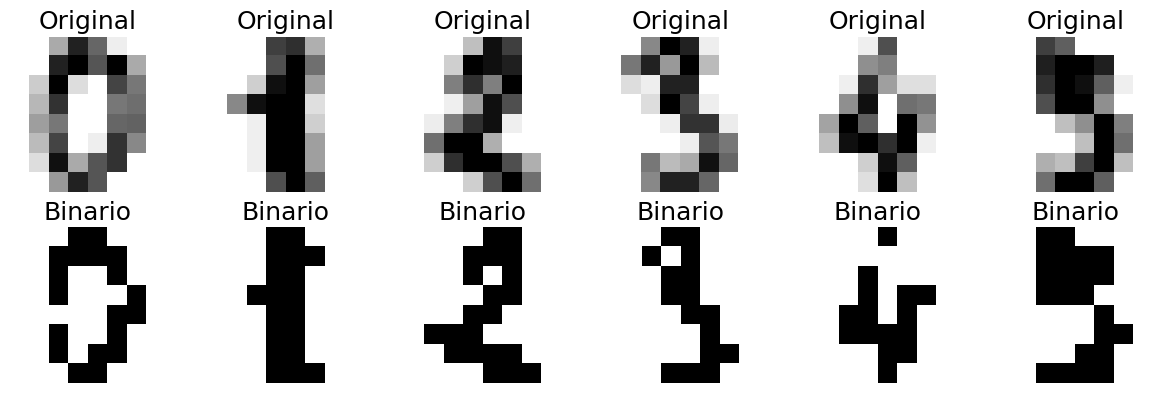

In [24]:
#Binarización del dataset
n_imagenes = 6

# Seleccionamos 6 patrones
indices = np.arange(n_imagenes)

fig, axes = plt.subplots(2, n_imagenes, figsize=(12, 4))

for j, idx in enumerate(indices):
    # Primera fila: patrones originales normalizados
    axes[0, j].imshow(X[idx].reshape(8, 8), cmap="gray_r")
    axes[0, j].set_title(f"Original",fontsize=18)
    axes[0, j].axis("off")

    # Segunda fila: patrones binarizados
    axes[1, j].imshow(X_bin[idx].reshape(8, 8), cmap="gray_r")
    axes[1, j].set_title("Binario",fontsize=18)
    axes[1, j].axis("off")

plt.tight_layout()
plt.savefig("dataset_digits.png", dpi=300, bbox_inches="tight", pad_inches=0.3)
plt.show()

In [25]:
#Definición de la energía
def energy_rbm(v, h, rbm):
    W = rbm.components_.T
    b = rbm.intercept_visible_
    c = rbm.intercept_hidden_

    return -v @ W @ h - b @ v - c @ h

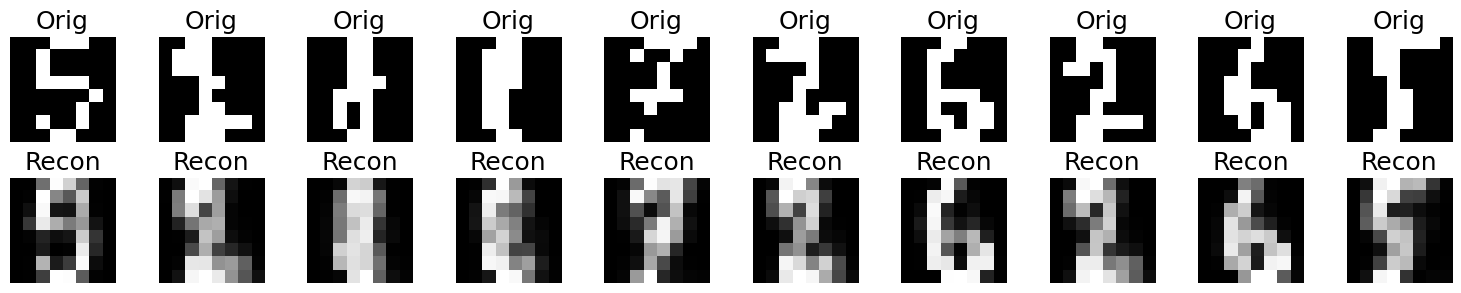

In [30]:
def reconstruct_rbm(model, X): #función de reconstrucción de imagenes
    H = model.transform(X)      #calcula a partir de la imagen X el valor de las variables ocultas, calcula P(h/v)
    V_recon_prob = 1 / (1 + np.exp(-(H @ model.components_ + model.intercept_visible_))) #reconstrucción de la capa visible a partir de H
    #es exactamente P(v/h)=sigma(W*h+b)
    return V_recon_prob

X_recon = reconstruct_rbm(rbm, X_test[:10])

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    axes[0, i].imshow(X_test[i].reshape(8, 8), cmap="gray") #en función de si es 0 o 1 asinga blanco y negro
    axes[0, i].axis("off")
    axes[0, i].set_title("Orig",fontsize=18)

    axes[1, i].imshow(X_recon[i].reshape(8, 8), cmap="gray") #en función del valor entre 0 y 1 asigna una escala de grises
    axes[1, i].axis("off")
    axes[1, i].set_title("Recon",fontsize=18)
plt.tight_layout()
plt.savefig("reconstruccion.png", dpi=300, bbox_inches="tight", pad_inches=0.3)
plt.show()


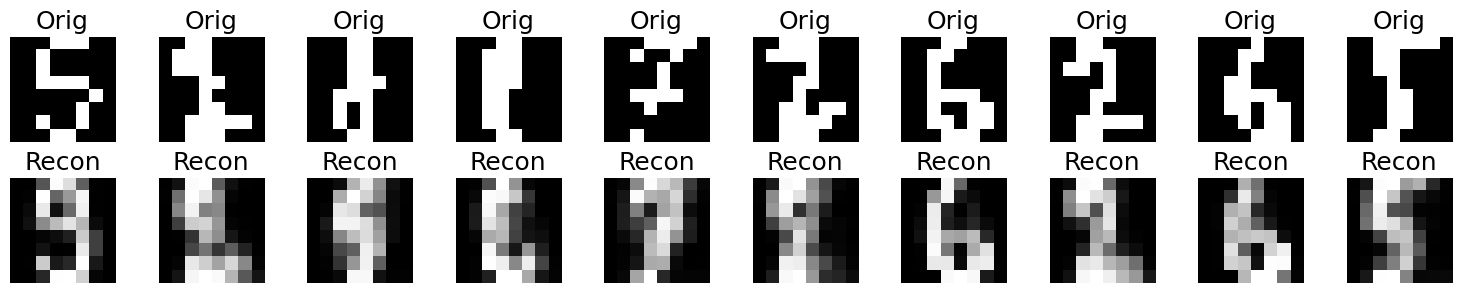

In [31]:
def reconstruct_rbm_stochastic(model, X, rng=None):
    rng = np.random.default_rng(rng)

    H_prob = model.transform(X)
    H_sample = rng.binomial(1, H_prob)

    V_prob = 1 / (1 + np.exp(-(H_sample @ model.components_ + model.intercept_visible_)))
    V_sample = rng.binomial(1, V_prob)

    return V_prob

X_recon = reconstruct_rbm_stochastic(rbm, X_test[:10])

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    axes[0, i].imshow(X_test[i].reshape(8, 8), cmap="gray") #en función de si es 0 o 1 asinga blanco y negro
    axes[0, i].axis("off")
    axes[0, i].set_title("Orig",fontsize=18)

    axes[1, i].imshow(X_recon[i].reshape(8, 8), cmap="gray") #en función del valor entre 0 y 1 asigna una escala de grises
    axes[1, i].axis("off")
    axes[1, i].set_title("Recon",fontsize=18)
plt.tight_layout()
plt.savefig("reconstruccion.png", dpi=300, bbox_inches="tight", pad_inches=0.3)
plt.show()

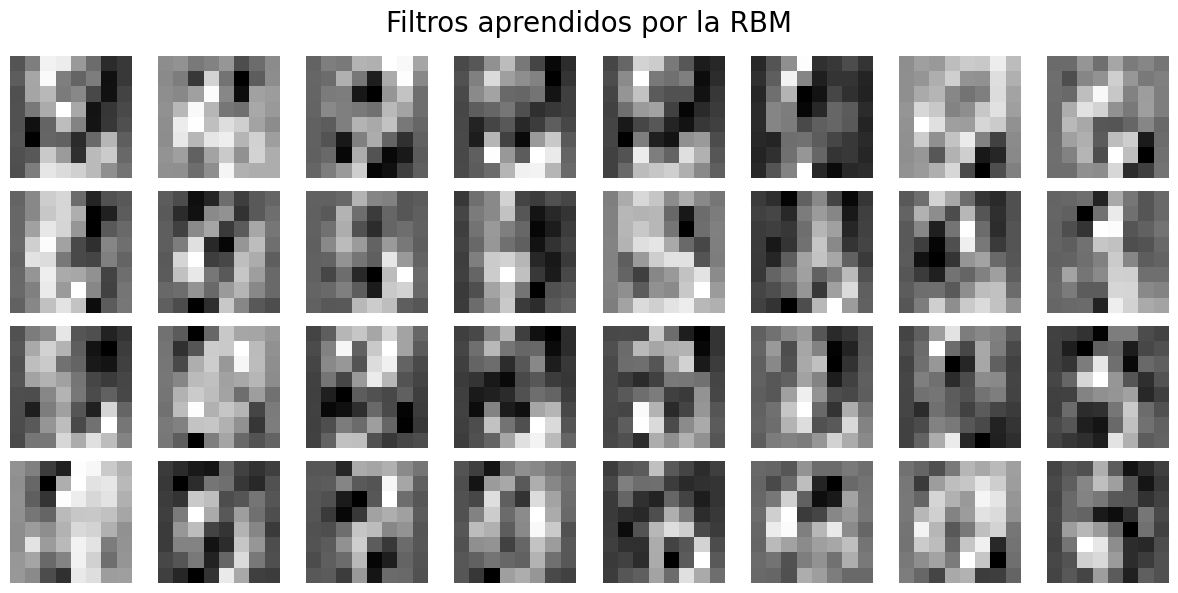

In [15]:
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for ax, comp in zip(axes.ravel(), rbm.components_[:32]): #rbm.components son los pesos aprendidos por la red(aunque solo se muestran los 36 primeros)
    ax.imshow(comp.reshape(8, 8), cmap="gray") #
    ax.axis("off")
plt.suptitle("Filtros aprendidos por la RBM",fontsize=20)
plt.tight_layout()
plt.savefig("filtros.png", dpi=300, bbox_inches="tight", pad_inches=0.3)
plt.show()



## 10. Conclusión
Este notebook puede usarse directamente como:

- base del **Capítulo 4** del TFG,
- anexo técnico,
- material para generar figuras y resultados del **Capítulo 5**.

Se recomienda guardar las figuras finales en alta resolución y fijar semillas aleatorias en los experimentos definitivos para garantizar reproducibilidad.
